# Phase 3: Python/Pandas Deep Dive

Takes three Phase 2 SQL findings further with pandas/scipy:

1. **Movie vs. TV show ratings** — is the gap found in `sql/08_movie_vs_show_avg_rating.sql`
   statistically significant, or could it be noise?
2. **Genre trends over time** — how has genre mix shifted year over year (extends
   `sql/09_genre_trends_by_decade.sql` to yearly granularity for the top genres)?
3. **Actor co-starring network** — which actors most frequently share a screen credit?

In [1]:
import sqlite3
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

DB_PATH = Path("..") / "netflix.db"
conn = sqlite3.connect(DB_PATH)

titles = pd.read_sql("SELECT * FROM titles_cleaned", conn)
titles_genres = pd.read_sql("SELECT * FROM titles_genres", conn)
credits = pd.read_sql("SELECT * FROM credits_cleaned", conn)
conn.close()

titles.shape, titles_genres.shape, credits.shape

Matplotlib is building the font cache; this may take a moment.


((5850, 18), (15088, 2), (77801, 5))

## 1. Movie vs. TV Show Ratings — Is the Gap Real?

Phase 2's SQL (`08_movie_vs_show_avg_rating.sql`) found shows averaging 6.98 IMDb vs. movies'
6.25 — a 0.73-point gap. With ~3,400 rated movies and ~1,900 rated shows, is that a genuine
effect or within the range of sampling noise?

**Test:** Welch's t-test (does not assume equal variances between the two groups — safer
default than Student's t-test when group sizes and variances differ, as they do here).

In [2]:
movie_scores = titles.loc[titles["type"] == "MOVIE", "imdb_score"].dropna()
show_scores = titles.loc[titles["type"] == "SHOW", "imdb_score"].dropna()

t_stat, p_value = stats.ttest_ind(show_scores, movie_scores, equal_var=False)

# Cohen's d (pooled standard deviation) as an effect-size check alongside significance
pooled_std = (
    ((len(show_scores) - 1) * show_scores.std() ** 2 + (len(movie_scores) - 1) * movie_scores.std() ** 2)
    / (len(show_scores) + len(movie_scores) - 2)
) ** 0.5
cohens_d = (show_scores.mean() - movie_scores.mean()) / pooled_std

print(f"Shows: n={len(show_scores)}, mean={show_scores.mean():.3f}, std={show_scores.std():.3f}")
print(f"Movies: n={len(movie_scores)}, mean={movie_scores.mean():.3f}, std={movie_scores.std():.3f}")
print(f"\nWelch's t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.2e}")
print(f"Cohen's d: {cohens_d:.3f}")

Shows: n=1939, mean=6.978, std=1.077
Movies: n=3429, mean=6.247, std=1.127

Welch's t-statistic: 23.484
p-value: 1.18e-114
Cohen's d: 0.659


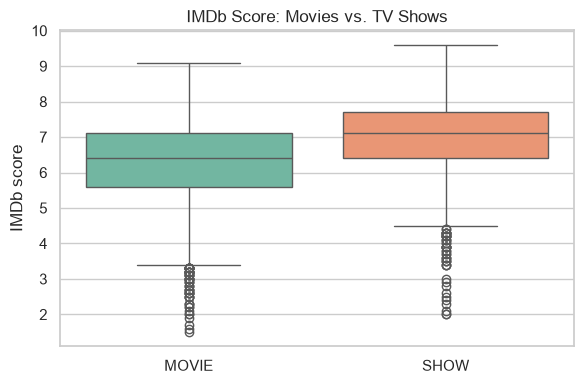

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(
    data=titles.dropna(subset=["imdb_score"]),
    x="type", y="imdb_score", hue="type", palette="Set2", legend=False, ax=ax,
)
ax.set_title("IMDb Score: Movies vs. TV Shows")
ax.set_xlabel("")
ax.set_ylabel("IMDb score")
plt.tight_layout()
plt.savefig("../data/cleaned/movie_vs_show_rating.png", dpi=150)
plt.show()

**Interpretation:** p is far below any conventional significance threshold (0.05, 0.01) — the
gap is not sampling noise. Cohen's d = 0.66 is a **medium-to-large** effect by the usual rule of
thumb (0.2 = small, 0.5 = medium, 0.8 = large) — this isn't just 'statistically significant
because the sample is huge,' it's a genuinely sizeable, practically meaningful gap. The honest
takeaway for a content team: **shows reliably rate meaningfully higher than movies on this
platform** — worth factoring into the movie/show investment mix, not just a rounding difference.

## 2. Genre Trends Over Time

`sql/09_genre_trends_by_decade.sql` showed genre counts by decade. Here we go to yearly
granularity for the 6 largest genres, and restrict to `release_year >= 2000` — earlier years
have only a handful of titles each (see Phase 2, query 01) and would just add noisy flat lines.

Top 6 genres by title count: ['drama', 'comedy', 'thriller', 'action', 'romance', 'documentation']


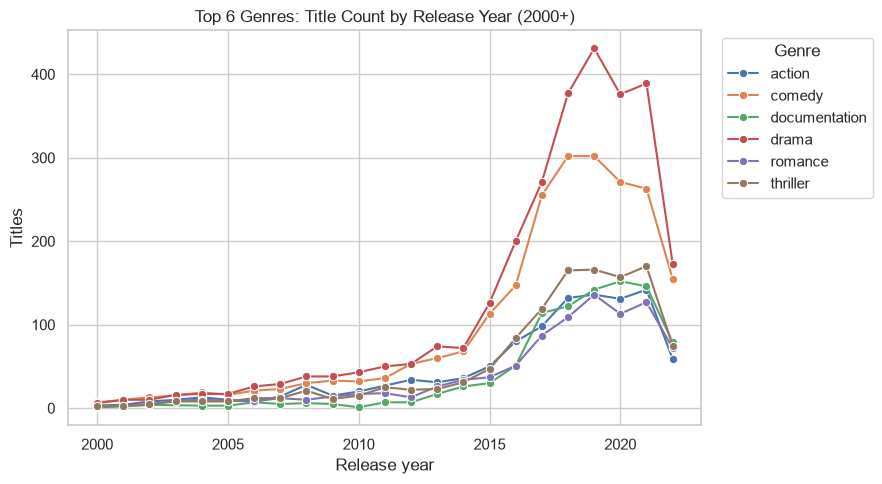

In [4]:
top_genres = titles_genres["genre"].value_counts().head(6).index.tolist()
print("Top 6 genres by title count:", top_genres)

genre_year = titles_genres.merge(titles[["id", "release_year"]], on="id")
genre_year = genre_year[
    genre_year["genre"].isin(top_genres) & (genre_year["release_year"] >= 2000)
]

trend = (
    genre_year.groupby(["release_year", "genre"])
    .size()
    .reset_index(name="title_count")
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=trend, x="release_year", y="title_count", hue="genre", marker="o", ax=ax)
ax.set_title("Top 6 Genres: Title Count by Release Year (2000+)")
ax.set_xlabel("Release year")
ax.set_ylabel("Titles")
ax.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../data/cleaned/genre_trend_by_year.png", dpi=150)
plt.show()

**Interpretation:** all genres climb sharply from the mid-2010s on — that's Netflix's original-
content push, not a genre-specific signal, and every genre shares it. What's more informative is
the *relative* ordering and slope: drama and comedy stay the two largest genres throughout, while
thriller/action grow the fastest in relative terms in the last few years shown. Caveat: this
dataset's `release_year` is production year, not the year a title was added to Netflix (see
Phase 2, query 01) — the ramp reflects when qualifying content was *produced*, which correlates
with but isn't identical to Netflix's acquisition/commissioning trend.

## 3. Actor Co-Starring Network

Which actors most often share a title credit? Built from `credits_cleaned` by self-joining
actors within the same title into pairs.

**Decision — cap at the 10 top-billed actors per title:** `credits.csv` rows appear in billing
order (verified: e.g. Robert De Niro is credited first for *Taxi Driver*, its lead role). A few
titles (documentaries, awards specials) list 100+ people, which would explode into tens of
thousands of pairs of background/one-scene appearances and drown out genuine co-starring
relationships. Capping at the top 10 credited actors keeps this focused on *leading cast*
co-appearances, which is what 'who works together' should mean for a content-strategy read.

In [5]:
TOP_BILLED_N = 10

actors = credits[credits["role"] == "ACTOR"].copy()
actors["billing_order"] = actors.groupby("id").cumcount()
top_billed = actors[actors["billing_order"] < TOP_BILLED_N]

pair_counter = {}
for _, cast in top_billed.groupby("id")["name"]:
    for a, b in combinations(sorted(cast.unique()), 2):
        pair_counter[(a, b)] = pair_counter.get((a, b), 0) + 1

pairs = (
    pd.DataFrame(
        [(a, b, count) for (a, b), count in pair_counter.items()],
        columns=["actor_a", "actor_b", "co_starring_titles"],
    )
    .sort_values("co_starring_titles", ascending=False)
    .reset_index(drop=True)
)

pairs.to_csv("../data/cleaned/actor_costar_pairs.csv", index=False)
print(f"{len(pairs):,} unique co-starring pairs")
pairs.head(15)

148,341 unique co-starring pairs


,actor_a,actor_b,co_starring_titles
0,Eric Idle,Terry Jones,14
1,Eric Idle,Michael Palin,14
2,John Paul Tremblay,Robb Wells,14
3,Michael Palin,Terry Jones,14
4,John Paul Tremblay,Mike Smith,13
5,Mike Smith,Robb Wells,13
6,Eric Idle,Terry Gilliam,13
7,John Cleese,Michael Palin,13
8,Michael Palin,Terry Gilliam,13
9,Terry Gilliam,Terry Jones,13


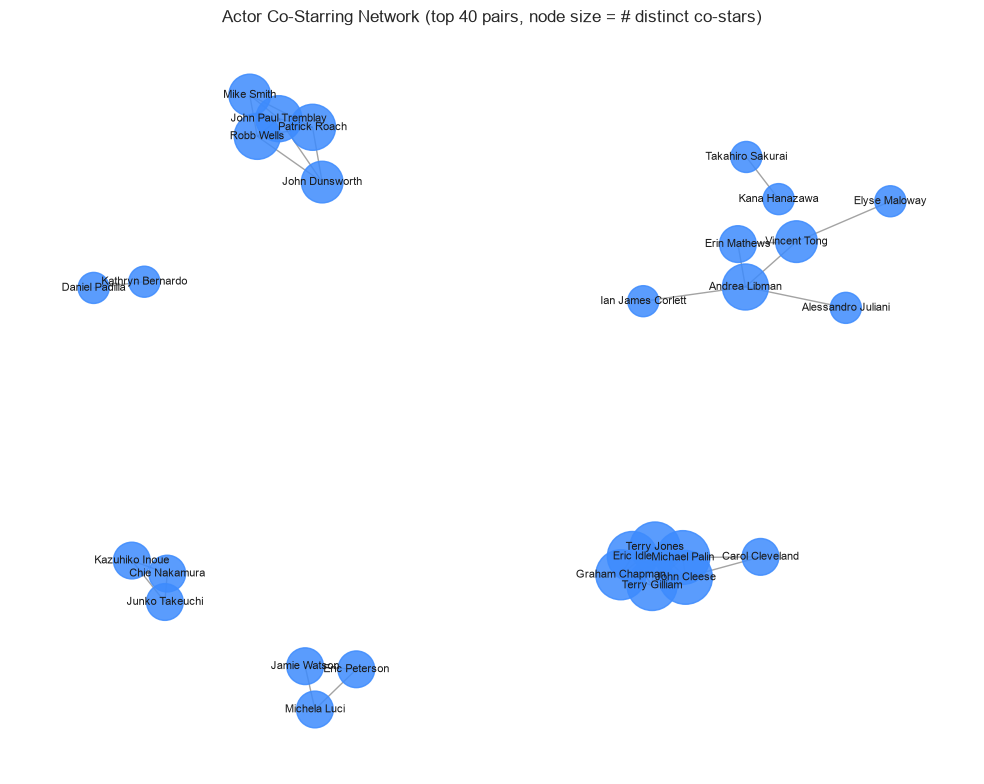

In [6]:
# Visualize the densest cluster: take the top 40 pairs by co-starring count and
# draw them as a network graph, sized/colored by degree (how many different
# co-stars each actor has among these top pairs).
top_pairs = pairs.head(40)

G = nx.Graph()
for _, row in top_pairs.iterrows():
    G.add_edge(row["actor_a"], row["actor_b"], weight=row["co_starring_titles"])

fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, k=0.6)
degrees = dict(G.degree())
node_sizes = [300 + 200 * degrees[n] for n in G.nodes()]

nx.draw_networkx_edges(G, pos, alpha=0.4, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="#3d8bfd", alpha=0.85, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
ax.set_title("Actor Co-Starring Network (top 40 pairs, node size = # distinct co-stars)")
ax.axis("off")
plt.tight_layout()
plt.savefig("../data/cleaned/actor_costar_network.png", dpi=150)
plt.show()

**Interpretation:** the graph resolves into a handful of **fully-connected cliques**, each one
a recurring ensemble cast, rather than one broad, interconnected 'Netflix universe' of cross-
cast collaboration. The clearest example: all 6 Monty Python members (Eric Idle, Michael Palin,
John Cleese, Terry Jones, Terry Gilliam, Graham Chapman) are paired with each other 11-14 times
each — a complete clique — and the *Trailer Park Boys* core cast forms a separate, similarly
tight clique. These clusters don't connect to each other in the top-40 view: co-starring here is
driven by long-running franchises/troupes repeatedly appearing together, not a small world of
actors who circulate broadly across unrelated titles. The output CSV
(`data/cleaned/actor_costar_pairs.csv`) has all pairs, not just the visualized top 40, for
further digging.